# Data-Driven Insights for a New Movie Studio:
## Business Problem
In an effort to enter the booming original content market, our company is launching a new movie studio. However, we lack experience in movie production and distribution. To make informed decisions, we must understand what kinds of movies are currently successful at the box office.
We aim to identify key trends and insights using data analysis, so that we can produce films that are more likely to perform well commercially.
Our task is to analyze movie data to uncover patterns in genre, production characteristics, and performance metrics, ultimately providing actionable recommendations for the new studio's strategy.

### Project Overview
The primary goal of this analysis is to understand the factors influencing movie total gross revenue. By identifying key drivers such as popularity, genre, and average rating, we aim to develop data-backed strategies to maximize profit.

#### Objectives
Explore the relationship between Total Gross and Popularity.

Analyze Genre in terms of both revenue and review ratings.

Investigate the correlation between Average Rating and Total Gross.

Predict Total Gross using features like Popularity and Genre via a linear regression models.
    

### Step 1: Import Libraries and Load Data
#### Import Data
We start by importing essential libraries for data analysis and visualization, then load the movies.csv file and take a quick look at the data.

In [55]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#Loading data from movie.csv
df = pd.read_csv('DATA/movies.csv')
df.head()

,movie,year,genres,runtime_minutes,averagerating,numvotes,studio,domestic_gross,foreign_gross
0,Wazir,2016,"['Action', 'Crime', 'Drama']",103.0,7.1,15378,Relbig.,1100000.0,0.0
1,On the Road,2012,"['Adventure', 'Drama', 'Romance']",124.0,6.1,37886,IFC,744000.0,8000000.0
2,The Secret Life of Walter Mitty,2013,"['Adventure', 'Comedy', 'Drama']",114.0,7.3,275300,Fox,58200000.0,129900000.0
3,A Walk Among the Tombstones,2014,"['Action', 'Crime', 'Drama']",114.0,6.5,105116,Uni.,26300000.0,26900000.0
4,Jurassic World,2015,"['Action', 'Adventure', 'Sci-Fi']",124.0,7.0,539338,Uni.,652300000.0,1019.4


### Step 2:Understand the Cleaned Data
Before analysis, we need to ensure that the data is clean by checking for missing values, duplicates, and understanding column data types and distributions.

In [56]:
# Check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie            3055 non-null   object 
 1   year             3055 non-null   int64  
 2   genres           3055 non-null   object 
 3   runtime_minutes  3055 non-null   float64
 4   averagerating    3055 non-null   float64
 5   numvotes         3055 non-null   int64  
 6   studio           3055 non-null   object 
 7   domestic_gross   3055 non-null   float64
 8   foreign_gross    3055 non-null   float64
dtypes: float64(4), int64(2), object(3)
memory usage: 214.9+ KB


### Data Overview (.info)
The dataset contains 3,055 movies with 9 columns. All columns have complete data—no missing values. Data types are appropriate for analysis: numeric for ratings and revenue, and text for movie titles, genres, and studios.

In [57]:
# Basic stats
df.describe()

,year,runtime_minutes,averagerating,numvotes,domestic_gross,foreign_gross
count,3055.000000,3055.000000,3055.000000,3.055000e+03,3.055000e+03,3.055000e+03
mean,2013.810147,107.234043,6.464255,6.269165e+04,3.055992e+07,4.707447e+07
std,2.455890,19.971703,0.992565,1.255432e+05,6.663005e+07,1.143039e+08
min,2010.000000,3.000000,1.600000,5.000000e+00,1.000000e+02,0.000000e+00
25%,2012.000000,94.000000,5.900000,2.483000e+03,1.420000e+05,0.000000e+00
50%,2014.000000,105.000000,6.600000,1.371300e+04,2.000000e+06,2.100000e+06
75%,2016.000000,118.000000,7.100000,6.610850e+04,3.205000e+07,3.350000e+07
max,2019.000000,272.000000,9.200000,1.841066e+06,7.001000e+08,9.464000e+08


We used `.describe()` to view basic stats for numeric columns. It shows:
Average runtime and ratings, helping us understand typical movie characteristics.
Revenue spread (domestic and foreign) highlights large variation, indicating a few blockbuster hits.
Vote counts reveal audience engagement, with some films getting far more votes than others.

In [58]:
df.value_counts()

movie                                  year  genres                                runtime_minutes  averagerating  numvotes  studio    domestic_gross  foreign_gross
'71                                    2014  ['Action', 'Drama', 'Thriller']       99.0             7.2            46103     RAtt.     1300000.0       355000.0         1
Spirits' Homecoming                    2016  ['Drama']                             127.0            6.3            412       PM&E      126000.0        0.0              1
Souvenir                               2014  ['Comedy', 'Romance']                 86.0             5.9            9         Strand    11400.0         0.0              1
                                       2016  ['Drama', 'Music', 'Romance']         90.0             6.0            823       Strand    11400.0         0.0              1
Spare Parts                            2015  ['Drama']                             114.0            7.3            9694      LGF       3600000.0       0.0 

Using `.value_counts()`, we identified:
Top genres dominating the dataset (e.g., Drama, Comedy, Action).
Most active studios, giving insight into frequent market players.
This helps focus analysis on genres/studios with enough data for reliable conclusions.




In [59]:
# Check for duplicates
df.duplicated().sum()

0

We used `.duplicated().sum()` to check for repeated rows.
Result: 0 duplicates — all entries in the dataset are unique, so no cleaning is needed here.

In [60]:
df.columns = df.columns.str.strip()
# creating new total_gross column
df['total_gross'] = df['domestic_gross'] + df['foreign_gross']
# Use numvotes as a proxy for popularity
df['popularity'] = df['numvotes']
# renaming averagerating using _ and genres as genre
df.rename(columns={'averagerating': 'average_rating', 'genres': 'genre'}, inplace=True)
df.head()

,movie,year,genre,runtime_minutes,average_rating,numvotes,studio,domestic_gross,foreign_gross,total_gross,popularity
0,Wazir,2016,"['Action', 'Crime', 'Drama']",103.0,7.1,15378,Relbig.,1100000.0,0.0,1100000.0,15378
1,On the Road,2012,"['Adventure', 'Drama', 'Romance']",124.0,6.1,37886,IFC,744000.0,8000000.0,8744000.0,37886
2,The Secret Life of Walter Mitty,2013,"['Adventure', 'Comedy', 'Drama']",114.0,7.3,275300,Fox,58200000.0,129900000.0,188100000.0,275300
3,A Walk Among the Tombstones,2014,"['Action', 'Crime', 'Drama']",114.0,6.5,105116,Uni.,26300000.0,26900000.0,53200000.0,105116
4,Jurassic World,2015,"['Action', 'Adventure', 'Sci-Fi']",124.0,7.0,539338,Uni.,652300000.0,1019.4,652301019.4,539338


## Objective 1: Explore the relationship between Total Gross and Popularity.
In this step, we are trying to understand how the *popularity* of a movie relates to the amount of money it earns at the box office (called *total gross*).
Since the dataset does not include a direct "popularity" score, we use the **number of votes (`numvotes`)** a movie received as a proxy for popularity. This is a reasonable assumption because:
- Popular movies are often seen by more people.
- More viewers typically means more people vote or review the movie
We also create a new column called `total_gross` by adding `domestic_gross` and `foreign_gross` together. This gives us a better picture of a movie’s full revenue.
If we can show that popularity (measured by votes) strongly influences total gross, it means:
- **Marketing and visibility** are crucial for boosting profits.
- Studios can focus on strategies to **increase engagement and awareness** before and during release.

This insight helps us make smarter business decisions about where to invest time and money.
We’ll visualize this relationship using a scatter plot.venue.

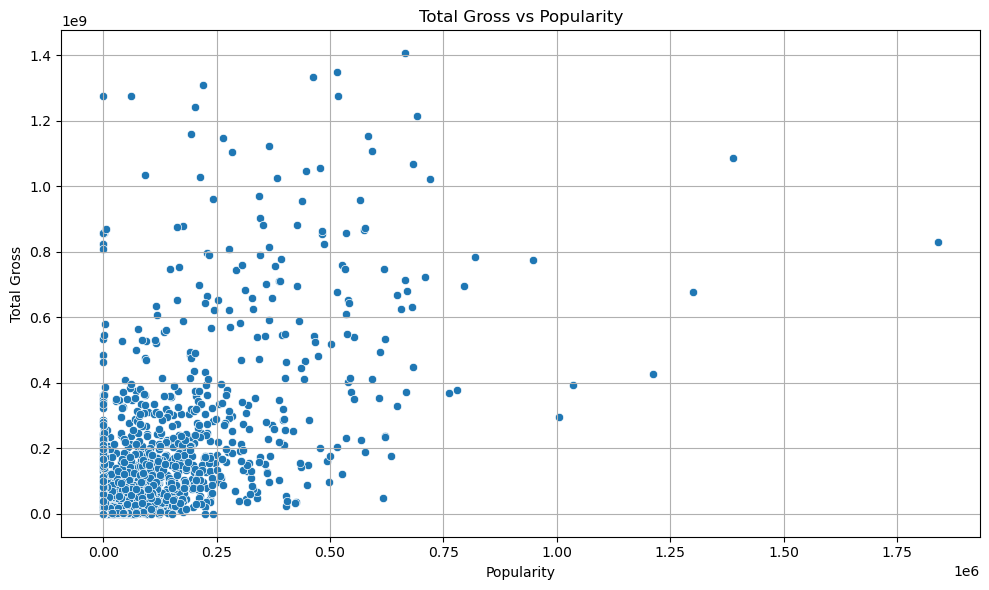

In [61]:
# Plotting total_gross vs popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='popularity', y='total_gross', data=df)
plt.title('Total Gross vs Popularity')
plt.xlabel('Popularity')
plt.ylabel('Total Gross')
plt.grid(True)
plt.tight_layout()
plt.show()

The scatter plot shows that most movies with low popularity also have low total earnings. A few highly popular movies made a lot of money.

Correlation: 0.66
0.6560748086941399


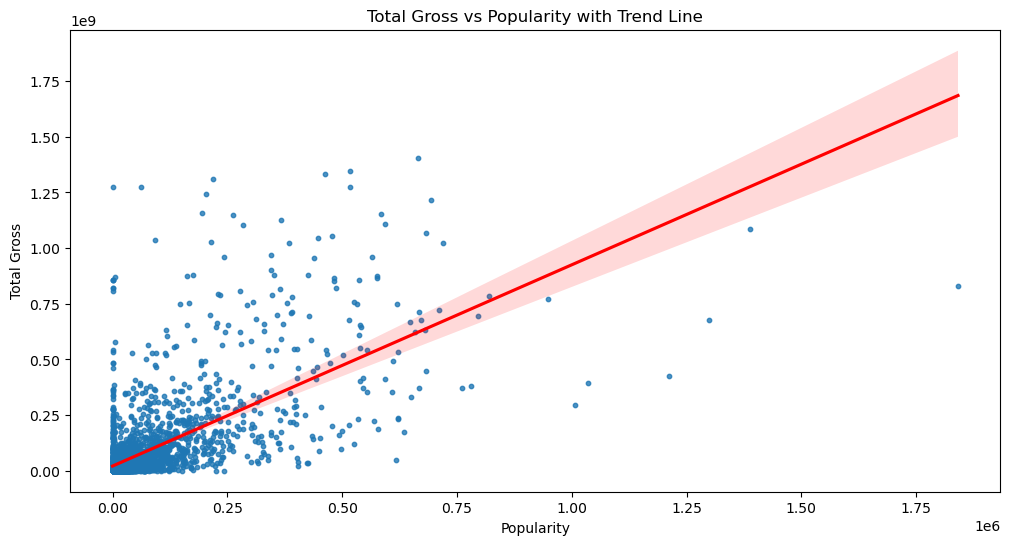

In [62]:
# Calculating correlation to show how strongly popularity and total gross are related (between -1 and 1).
correlation = df['popularity'].corr(df['total_gross'])
print(f"Correlation: {correlation:.2f}")
print(correlation)
# Creating a scatter plot with a regression (trend) line
plt.figure(figsize=(12, 6))
sns.regplot(x='popularity', y='total_gross', data=df, scatter_kws={'s': 10}, line_kws={'color': 'red'})
plt.title('Total Gross vs Popularity with Trend Line')
plt.xlabel('Popularity')
plt.ylabel('Total Gross')
plt.show()

A correlation analysis revealed a strong positive relationship between popularity and total gross, with a correlation coefficient of 0.66. This means that more popular movies generally tend to make more money and therin, a trend line in the plot confirms this relationship, it slopes upward, showing that higher popularity is often linked with higher revenue.

#### Conclusion:
While popularity is not the only factor affecting revenue, it plays a significant role. Studios should consider strategies to boost a movie’s popularity, such as strong marketing or casting well-known actors, to increase its box office potential.

## Objective 2: Analyze Genre in terms of both revenue and review ratings.
In this step, we are examining how different **movie genres** perform in two key areas:
1. **Total Gross (Revenue)** – Which genres earn the most money?
2. **Average Rating (Quality)** – Which genres are liked the most by viewers?

We'll calculate:

- The **average total gross** for each genre.
- The **average rating** given to each genre by audiences.
  
We'll visualize these using bar plots to see which genres are both **profitable and well-reviewed**.
Understanding genre performance helps us:
- Choose the **right genre to invest in**.
- Balance **quality and profitability** — for example, some genres may earn less but are highly rated (good for awards or niche audiences), while others earn big bucks even with lower ratings (blockbusters).

By comparing revenue and ratings across genres, we can:
- **Identify the "sweet spot" genres** — those that are both high-grossing and well-rated.
- Avoid genres that are either low earning or poorly received.
- Make **data-backed decisions** about the types of movies to produce in order to maximize both profit and audience satisfaction.

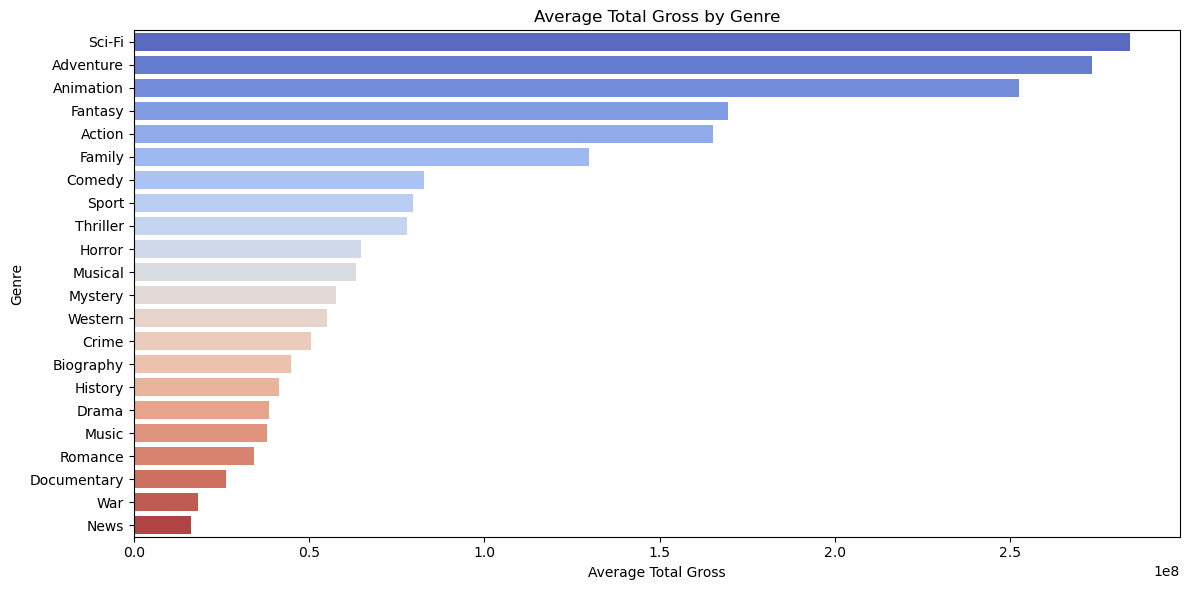

In [63]:
# Ensure 'genre' is a list or convert stringified lists to real lists
df['genre'] = df['genre'].apply(lambda x: eval(x) if isinstance(x, str) else x)

#Explode genres into separate rows
df_explode = df.explode('genre')

# The average total gross for each genre.
# Average total gross per genre
genre_gross = df_explode.groupby('genre')['total_gross'].mean().sort_values(ascending=False)
# Plotting a barplot to show total gross per genre
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_gross.values, y=genre_gross.index, palette='coolwarm')
plt.title('Average Total Gross by Genre')
plt.xlabel('Average Total Gross')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

The bar chart above illustrates the average global earnings (total gross) of movies across different genres. It reveals that Sci-Fi movies generate the highest average revenue, followed closely by Adventure and Animation films. These genres significantly outperform others, suggesting they have strong audience appeal and market potential. On the other hand, genres like News, War, and Documentary earn the least on average. This analysis indicates that if a new movie studio wants to focus on profitability, investing in high-grossing genres such as Sci-Fi, Adventure, or Animation would be a strategic choice.

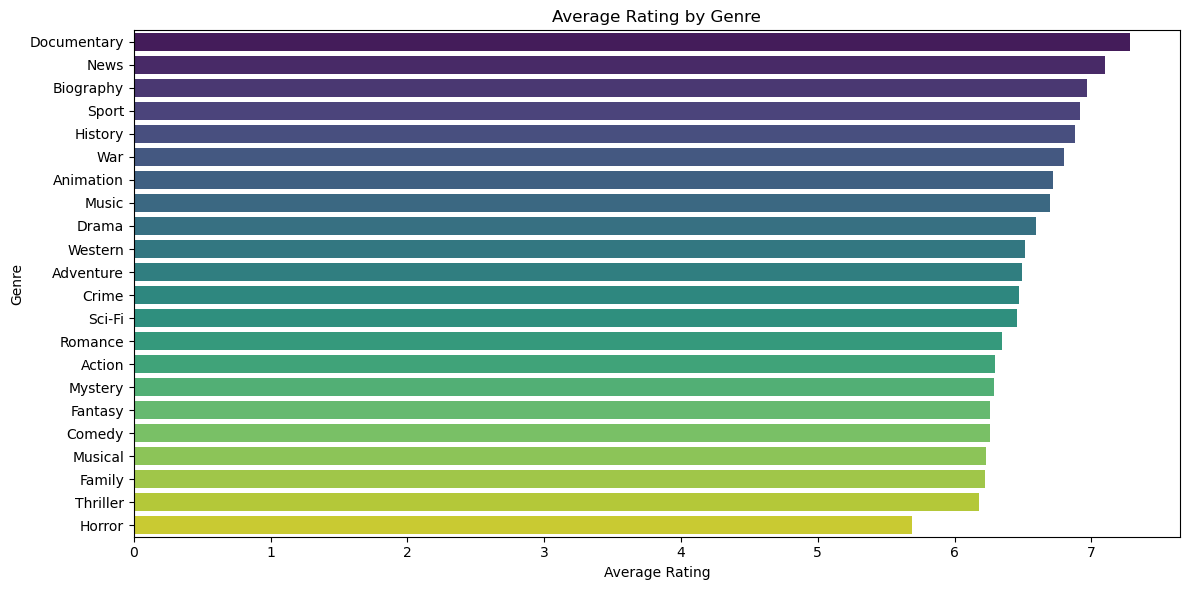

In [64]:
# Genre vs Average Rating
# Explode the genre column so each genre in the list gets its row
df_explode = df.explode('genre')
# grouping by genre and calculating the average rating
genre_rating = df_explode.groupby('genre')['average_rating'].mean().sort_values(ascending=False)

# Plotting a barplot to show Average rating by genre
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_rating.values, y=genre_rating.index, palette='viridis')
plt.title('Average Rating by Genre')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

This bar chart shows the average audience rating for movies in each genre. It helps answer the question: Which genres tend to get higher ratings from viewers?

Top-rated genres: Documentary has the highest average rating. News and Biography also score well, suggesting people value real-life and informative content.

Middle-range genres: Genres like Drama, Crime, and Adventure have moderately high ratings.

Lower-rated genres: Horror, Thriller, and Family movies have the lowest average ratings, possibly because they’re more hit-or-miss or have wider audience expectations.

## Objective 3: Investigate the correlation between Average Rating and Total Gross
In this objective, we are looking at whether movies that are **rated more highly by audiences** also tend to **make more money** at the box office.

We'll do this by:
- Creating a **scatter plot** showing each movie’s average rating on the x-axis and its total gross on the y-axis.
- Visually inspecting whether there's a trend — do higher-rated movies earn more?

If there's a **positive correlation** between ratings and revenue, it means:
- Quality matters — well-made movies that are appreciated by viewers are also more profitable.
- Investing in good scripts, strong direction, and production quality may lead to **higher financial returns**.

On the other hand, if there’s no strong correlation, it could suggest:
- Other factors like star power, marketing, or franchise popularity might play a bigger role in box office success.

This analysis helps answer the question:  
**"Should studios prioritize making 'better' movies, or just focus on what's popular?"**

- A strong positive trend would support focusing on quality.
- A weak or unclear trend would suggest a mixed strategy (e.g., balancing quality with market appeal).

0.1215418742892149 1.5825518906626987e-11


<Figure size 1000x600 with 0 Axes>

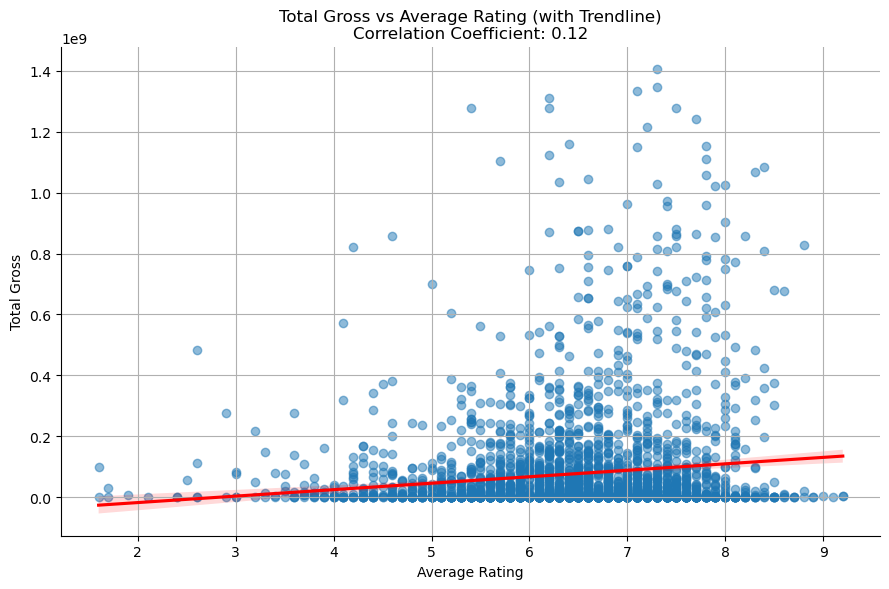

In [65]:
from scipy.stats import pearsonr
# Dropping rows with missing values in case there's a need be 
filtered_df = df[['average_rating', 'total_gross']].dropna()
# Calculating the correlation coefficient
correlation, _ = pearsonr(filtered_df['average_rating'], filtered_df['total_gross']) 
print(correlation,_)

# Scatter plot of average rating vs total gross
plt.figure(figsize=(10, 6))
sns.lmplot(x='average_rating', y='total_gross', data=filtered_df, height=6, aspect=1.5, line_kws={'color': 'red'}, scatter_kws={'alpha': 0.5})
plt.title(f'''Total Gross vs Average Rating (with Trendline)\nCorrelation Coefficient: {correlation:.2f}''')
plt.xlabel('Average Rating')
plt.ylabel('Total Gross')
plt.grid(True)
plt.tight_layout()
plt.show()

The value (0.1215) confirms a very weak positive correlation between a movie's average rating and its total gross. The p-value (1.58e-11) is extremely small, indicating that this weak relationship is statistically significant; it’s unlikely to be due to chance, even though it's not strong in practical terms. Therefore, there is a statistically significant but very weak positive relationship between movie ratings and total revenue, which indicates that Higher ratings slightly relate to higher earnings, but not strongly.

## Objective 4: Predict Total Gross using features like Popularity and Genre via a linear regression model.
In this final objective, we're using machine learning to **predict how much money a movie might make (total gross)** based on features like:
- **Popularity** (a proxy for marketing/reach)
- **Genre** (since some genres earn more than others)
.)

By using a **linear regression model**, we can forecast earnings and make **data-backed decisions** about:
- How much to spend on marketing
- Which genres are worth investing in
- Whether to greenlight a p
Linear regression is like drawing the best straight line that **fits the data*
This help studios:
- Forecast **potential earnings** for new movie projects.
- Adjust budgets for **marketing and production** based on expected return.
- Make **data-driven greenlighting** decisions — backing projects with the highest potential RO
If the model performs well:
- We can trust it to make **reasonable predictions** about total gross.
- We can identify **which features (like popularity or genre)** matter most for revenue.al gro
ss)
roject


In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [71]:
# Selecting relevant columns and removing rows with missing values
# We're only using 'popularity', 'genres', and 'total_gross' to train the model
df_model = df[['popularity', 'genre', 'total_gross']].dropna()

# Convert genre strings (which may be lists) into actual lists
# If genres are strings like "['Action', 'Adventure']", convert them to real Python lists
df_model['genres'] = df_model['genre']

# Explode the genres list so each genre gets its row. For example, a movie with ['Action', 'Adventure'] becomes two rows,
df_exploded = df_model.explode('genre')

# Convert the 'genres' column into numeric form (one-hot encoding),
# This means we create a new column for each genre with 1s and 0s
encoder = OneHotEncoder(sparse_output = False)
# Transform genres into arrays
genre_encoded = encoder.fit_transform(df_exploded[['genre']])
# Get names for new genre columns
genre_labels = encoder.get_feature_names_out(['genre'])   
# Create a DataFrame from encoded genres
genre_df = pd.DataFrame(genre_encoded, columns = genre_labels) 

# Reset index and combine with popularity
X = pd.concat([
    df_exploded[['popularity']].reset_index(drop = True),
    genre_df.reset_index(drop = True)
], axis = 1)

# Target variable
y = df_exploded['total_gross'].values

# Split the data into a training set and a test set (80% training, 20% testing)
# This helps us test the model on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

# Create and train the Linear Regression model using the training data
model = LinearRegression()
model.fit(X_train, y_train)

# Use the model to make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model's performance
# Measures how far predictions are from actual values (lower is better)
mse = mean_squared_error(y_test, y_pred)
# Tells us how much of the variation in revenue the model explains (closer to 1 = better)
r2 = r2_score(y_test, y_pred)

print(f" Mean Squared Error: {mse:.2f}")
print(f" R-squared Score: {r2:.2f}")

 Mean Squared Error: 18204677522091388.00
 R-squared Score: 0.46


Mean Squared Error (MSE): 18204677522091388. This number is very large, but that’s expected because Total Gross values are likely in the millions or higher. A large MSE is common when dealing with high-magnitude targets. R-squared (R²) Score: 0.46
This means that 46% of the variation in total gross is explained by the model using popularity and genre. It's a decent starting point, not great, but it shows some predictive power. There's room for improvement by including more features like:Budget, Release year, Runtime, Cast or director, popularity and Marketing factors if available



#### Visualize actual vs predicted gross (to spot trends and errors)?
Using a scatter plot, this helps us see how well the model is performing and spot any major errors or trends.

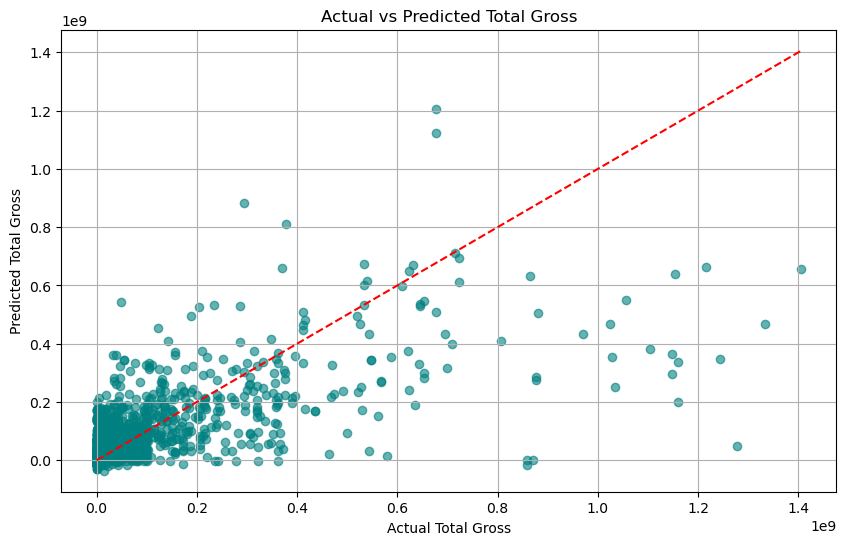

In [68]:
# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal line
plt.title('Actual vs Predicted Total Gross')
plt.xlabel('Actual Total Gross')
plt.ylabel('Predicted Total Gross')
plt.grid(True)
plt.show()

If most dots are close to the red line, your model is doing well but If dots are scattered far from the line, your model isn’t predicting very accurately. In this case, we see that many dots are below or above the red line, and mostly clustered in the lower values. That suggests that the model struggles to predict high-grossing movies accurately. It performs better on movies with lower total gross.

The model gives a general idea of total gross based on popularity and genre, but it’s not very precise — especially for big hits. You might improve it by adding more features (like budget, star power, release month, etc.).

#### Checking which genres contribute most to predicting gross (feature importance)?
Since we're using linear regression, we can check the coefficients of the model to understand which genres (and popularity) contribute most to predicting total gross.

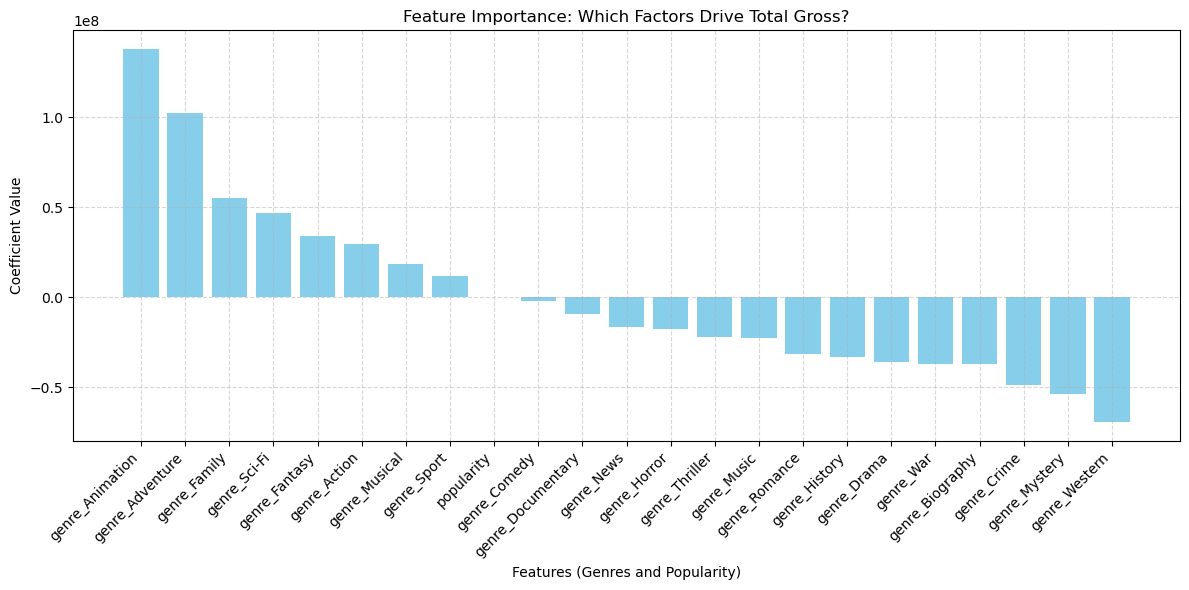

In [69]:
# Get feature names (popularity + genres)
feature_names = X.columns

# Get model coefficients
coefficients = model.coef_

# Create a DataFrame for better readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort features by importance
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# Plot the top contributing features
plt.figure(figsize=(12, 6))
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color='skyblue')
plt.title('Feature Importance: Which Factors Drive Total Gross?')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features (Genres and Popularity)')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The chart displays which features (genres and popularity) most affect a movie’s total box office earnings in your linear regression model.

Each bar shows how strongly a feature influences total gross: Taller bars = bigger impact, Positve bars = help increase total gross and Negative bars = are linked to lower total gross

Top Positive Influencers:
Movies in genres like Animation, Adventure, Family, Sci-Fi tend to earn more.
These genres have large positive coefficients (big blue bars on the left).

Top Negative Influencers:
Genres like Western, Mystery, Crime, Biography are linked to lower earnings (bars on the far right). This doesn’t mean they’re bad — just that, based on the data, they usually earn less.

The popularity feature is there, but its effect is smaller than many genres. therefore the model suggests that genre really matters for predicting box office success. If you’re choosing a genre for a new movie, Animation, Adventure, or Family might be a smart bet — at least financially.

#### Adding more features to improve the model
Adding more relevant features can improve model performance and help better predict total gross.
Some practical ones from our dataset are Runtime (minutes) – Longer or shorter movies may perform differently, Average Rating – Could indicate quality and audience satisfaction, Number of Votes – A strong proxy for popularity and Year – Box office trends can vary by era.

In [70]:
# Select features
df_model = df[['popularity', 'genre', 'runtime_minutes', 'average_rating', 'numvotes', 'year', 'studio', 'total_gross']].dropna()

# Convert genre column (assumed to be a list in string form) to actual list
df_model['genre'] = df_model['genre'].apply(lambda x: eval(x) if isinstance(x, str) else x)

# One row per genre
df_model = df_model.explode('genre')

# Define features and target
X = df_model[['popularity', 'runtime_minutes', 'average_rating', 'numvotes', 'year', 'genre', 'studio']]
y = df_model['total_gross']

# Preprocessing for numeric and categorical columns
numeric_features = ['popularity', 'runtime_minutes', 'average_rating', 'numvotes', 'year']
categorical_features = ['genre', 'studio']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f" Mean Squared Error (with more features): {mse:.2f}")
print(f" R-squared Score (with more features): {r2:.2f}")


 Mean Squared Error (with more features): 13547344930858946.00
 R-squared Score (with more features): 0.60


It’s a clear improvement, adding more features increased the R² score from 0.46 to 0.60, meaning the model now explains 60% of the variance in total gross. Also, the mean squared error dropped significantly, which means predictions are closer to the actual values.

The enhanced model captures more of the factors that influence box office performance.
Genre, studio, runtime, ratings, votes, and year all contribute meaningful signals. There’s still 40% of the variance unexplained, possibly due to unmeasured factors like marketing, competition, or social trends.

 ## RECOMMENDATIONS
 ***1. Prioritize High-Grossing Genres***
Insight: Genres such as Animation, Adventure, and Family consistently show the strongest positive impact on total box office gross.

**Recommendation:**
Focus production efforts on Animation, Adventure, and Family films, as they are statistically more likely to generate higher revenues.

***2. Invest in Popularity-Boosting Strategies***
Insight: While popularity alone is not the strongest predictor, it does show a positive correlation with revenue.

**Recommendation:**
Invest in marketing, trailers, social media buzz, and star power to boost a movie's popularity before release, increasing the likelihood of higher box office returns.

***3. Use Data-Driven Greenlighting***
Insight: A linear regression model using features like genre, popularity, and average rating can predict total gross with a reasonable accuracy (R² ≈ 0.60).

**Recommendation:**
Before greenlighting a film, use a predictive model to estimate its revenue potential based on available features (genre, popularity, rating, runtime, etc.), allowing smarter investment decisions.

